# Graph RAG: Safe Text-to-Cypher Question Answering

**Chapter 23: Knowledge Graphs for Financial AI**

**Docker image**: `ml4t`

> **Neo4j required**: This notebook queries a Neo4j graph database.
> Start Neo4j first, then run the notebook:
> ```bash
> docker compose --profile kg up -d neo4j
> docker compose run --rm ml4t python 23_knowledge_graphs/03_graph_rag_qa.py
> ```


This notebook demonstrates a safe Graph RAG workflow over the real 13F
institutional holdings graph loaded into Neo4j by `05_institutional_holdings_kg`.

**Learning Objectives**:
- Route a question to a pre-written Cypher template instead of generating Cypher
- Validate Cypher against a read-only schema policy, and see what such a policy misses
- Enforce dated queries and row limits against queries written to defeat them
- Audit the validator with a hostile control set, not only with queries built to pass

**Book Reference**: Chapter 23, Section 23.3 (Graph RAG: Deterministic Relational Reasoning)

**Prerequisites**: Run `05_institutional_holdings_kg` to load the 13F graph into
Neo4j. This notebook requires a live Neo4j connection and does not use canned
query results.

In [1]:
"""Run controlled read-only Cypher queries over institutional holdings."""

from __future__ import annotations

import hashlib
import json
import logging
import os
import re
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
from neo4j import GraphDatabase, Query

from utils.style import COLORS, FIGSIZE, add_message_title, show_with_alt

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

In [2]:
ROW_LIMIT = 25
TIMEOUT_SECONDS = 2.0
# Point-in-time as-of date: holdings that became public after it are invisible to
# the queries. Left empty, it is read from the producer's GraphSnapshot node, so
# the notebook does not restate a date the artifact owns. An earlier date passed
# here is honoured; a later one is refused, because the graph cannot answer for a
# date it has no filings for. This field held the literal "2026-02-17" and broke
# the first time the 13F artifact rolled a quarter forward.
CUTOFF_DATE = ""

## 1. Neo4j Connection and Safety Policy

In [3]:
NEO4J_URI = os.getenv("NEO4J_URI", "bolt://localhost:7687")
NEO4J_USER = os.getenv("NEO4J_USER", "neo4j")
NEO4J_PASSWORD = os.getenv("NEO4J_PASSWORD", "password")

NEO4J_DRIVER = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))
NEO4J_DRIVER.verify_connectivity()
print(f"Neo4j connected: {NEO4J_URI}")

GRAPH_SCHEMA: dict[str, Any] = {
    "labels": {"Institution", "Stock", "Sector"},
    "relationships": {"HOLDS", "IN_SECTOR"},
    "properties": {
        "available_from",
        "cik",
        "cusip",
        "equity_13f_value",
        "issuer",
        "label",
        "name",
        "report_date",
        "sector",
        "shares",
        "value",
    },
}

BLOCKED_KEYWORDS = {
    "CALL",
    "CREATE",
    "DELETE",
    "DETACH",
    "DROP",
    "LOAD CSV",
    "MERGE",
    "REMOVE",
    "SET",
}

print("Schema labels:", sorted(GRAPH_SCHEMA["labels"]))
print("Schema relationships:", sorted(GRAPH_SCHEMA["relationships"]))

Neo4j connected: bolt://neo4j:7687
Schema labels: ['Institution', 'Sector', 'Stock']
Schema relationships: ['HOLDS', 'IN_SECTOR']


### Producer Snapshot Contract

The query layer accepts only the fixed-cohort graph produced from the current 13F bytes.

In [4]:
source_path = (
    Path(os.environ["ML4T_DATA_PATH"])
    / "equities"
    / "positioning"
    / "13f"
    / "institutional_holdings.parquet"
)
expected_source_hash = hashlib.sha256(source_path.read_bytes()).hexdigest()
with NEO4J_DRIVER.session(default_access_mode="READ") as session:
    snapshot_record = session.run(
        "MATCH (s:GraphSnapshot {name: 'ch23_13f'}) RETURN properties(s) AS snapshot"
    ).single()
    graph_counts = (
        session.run(
            """
        MATCH (i:Institution) WITH count(i) AS institutions
        MATCH (s:Stock) WITH institutions, count(s) AS stocks
        MATCH (:Institution)-[h:HOLDS]->(:Stock)
        WITH institutions, stocks, count(h) AS holdings
        MATCH (:Stock)-[r:IN_SECTOR]->(:Sector)
        RETURN institutions, stocks, holdings, count(r) AS sector_edges
        """
        )
        .single()
        .data()
    )
assert snapshot_record is not None, "Run 05_institutional_holdings_kg before this notebook"
GRAPH_SNAPSHOT = snapshot_record["snapshot"]
assert GRAPH_SNAPSHOT["source_sha256"] == expected_source_hash
assert GRAPH_SNAPSHOT["cohort_policy"] == "earliest-report-period formation, fixed forward"
assert graph_counts == {
    "institutions": GRAPH_SNAPSHOT["institution_count"],
    "stocks": GRAPH_SNAPSHOT["stock_count"],
    "holdings": GRAPH_SNAPSHOT["holding_count"],
    "sector_edges": GRAPH_SNAPSHOT["stock_count"],
}

# The producer owns the as-of date; this notebook reads it rather than restating
# it. An override earlier than the graph's latest availability is a legitimate
# question ("what did we know in November?"); a later one asks the graph about
# filings it does not have, and would silently answer as though it did.
LATEST_AVAILABLE = GRAPH_SNAPSHOT["latest_available_from"]
CUTOFF_DATE = CUTOFF_DATE or LATEST_AVAILABLE
assert CUTOFF_DATE <= LATEST_AVAILABLE, (
    f"cutoff {CUTOFF_DATE} is later than the graph's latest filing availability "
    f"{LATEST_AVAILABLE}; the graph cannot answer as of that date"
)
print(f"Validated graph snapshot: {GRAPH_SNAPSHOT}")
print(f"Answering as of {CUTOFF_DATE} (graph is complete through {LATEST_AVAILABLE})")

Validated graph snapshot: {'institution_count': 10, 'position_basis': 'long equity only; reported put and call rows excluded', 'formation_report_date': '2025-06-30', 'stock_count': 50, 'latest_report_date': '2026-03-31', 'source_sha256': 'd2a67317195dd431f00e3408c1ba4e6bf8b44b3eae2f838cbbd90fabca69ef0d', 'latest_available_from': '2026-05-15', 'holding_count': 1463, 'name': 'ch23_13f', 'report_period_count': 4, 'source_rows': 209316, 'cohort_policy': 'earliest-report-period formation, fixed forward'}
Answering as of 2026-05-15 (graph is complete through 2026-05-15)


## 2. Question Routing, Not Cypher Generation

Nothing below writes Cypher. Three templates are written by hand with their
parameters fixed, and a question is matched to one of them; the entity named
in the question is never read out of it. That is a defensible design for a
system that must not be talked into a query, and it is worth being plain about
what it is, because "text-to-Cypher" suggests the question shapes the query and
here it only chooses between three that already exist. A generated-Cypher
system needs the validator in section 3 to be sound. This one needs it only as
a second line.

Each template restricts HOLDS edges to those already public at the cutoff,
`h.available_from <= $cutoff_date`, and then keeps the latest report period
among those (`collect(h)[0]` after `ORDER BY h.report_date DESC`). Both dates
do work here and neither can stand in for the other: the cutoff is about what
was knowable, and the ordering is about which quarter the position describes.
Filtering on the report period would admit a filing that had not been made
yet, and ordering by availability would break the moment a manager filed two
quarters on the same day.

In [5]:
HOLDERS_SPEC = {
    "cypher": """
MATCH (i:Institution)-[h:HOLDS]->(s:Stock)
WHERE replace(s.issuer, " ", "") = replace($issuer, " ", "")
  AND h.available_from <= $cutoff_date
WITH i, s, h ORDER BY h.report_date DESC
WITH i, s, collect(h)[0] AS latest_h
RETURN i.name AS institution,
       latest_h.value AS position_value,
       latest_h.shares AS shares,
       latest_h.report_date AS report_date,
       latest_h.available_from AS available_from
ORDER BY position_value DESC
LIMIT 25
""".strip(),
    "params": {"issuer": "APPLE INC"},
    "kind": "holders",
}

In [6]:
CO_OWNERS_SPEC = {
    "cypher": """
MATCH (i:Institution)-[ha:HOLDS]->(a:Stock)
MATCH (i)-[hm:HOLDS]->(m:Stock)
WHERE replace(a.issuer, " ", "") = replace($issuer_1, " ", "")
  AND replace(m.issuer, " ", "") = replace($issuer_2, " ", "")
  AND ha.available_from <= $cutoff_date
  AND hm.available_from <= $cutoff_date
WITH i, a, m, ha, hm ORDER BY ha.report_date DESC, hm.report_date DESC
WITH i, a, m, collect(ha)[0] AS latest_a, collect(hm)[0] AS latest_m
RETURN i.name AS institution,
       latest_a.value AS issuer_1_value,
       latest_m.value AS issuer_2_value,
       latest_a.available_from AS issuer_1_available_from,
       latest_m.available_from AS issuer_2_available_from
ORDER BY issuer_1_value + issuer_2_value DESC
LIMIT 25
""".strip(),
    "params": {"issuer_1": "APPLE INC", "issuer_2": "MICROSOFT CORP"},
    "kind": "co_owners",
}

In [7]:
LARGEST_HOLDINGS_SPEC = {
    "cypher": """
MATCH (i:Institution {name: $institution})-[h:HOLDS]->(s:Stock)
WHERE h.available_from <= $cutoff_date
WITH i, s, h ORDER BY h.report_date DESC
WITH s, collect(h)[0] AS latest_h
RETURN s.issuer AS issuer,
       latest_h.value AS position_value,
       latest_h.shares AS shares,
       latest_h.report_date AS report_date,
       latest_h.available_from AS available_from
ORDER BY position_value DESC
LIMIT 10
""".strip(),
    "params": {"institution": "BERKSHIRE HATHAWAY INC"},
    "kind": "largest_holdings",
}

### Supported Question Router

In [8]:
QUESTION_SPECS = {
    "who holds apple": HOLDERS_SPEC,
    "which institutions own both apple and microsoft": CO_OWNERS_SPEC,
    "what are berkshire hathaway largest holdings": LARGEST_HOLDINGS_SPEC,
}


def route_question(question: str) -> tuple[str, dict[str, Any], str]:
    """Match a question to one of the three pre-written templates.

    The match is on the whole normalized question. Substring matching sent
    "who holds apple pie?" to the Apple holders template and answered it with a
    straight face, which is the failure mode a router has: it cannot say "I do
    not know" about a question it half-recognises unless it is made to.
    """
    normalized = question.lower().strip().rstrip("?")
    spec = QUESTION_SPECS.get(normalized)
    if spec is None:
        raise ValueError(f"Unsupported question: {question!r}. Supported: {sorted(QUESTION_SPECS)}")
    return spec["cypher"], {"cutoff_date": CUTOFF_DATE, **spec["params"]}, spec["kind"]

## 3. Safety Validation

The validator is a text policy over Cypher, and section 6 runs a set of
queries written to get past it. Four of the checks below exist because an
earlier version of this validator accepted something it should not have, and
each carries the query that got through.

In [9]:
# `(?<![A-Za-z0-9_])` keeps function calls out: `replace(s.issuer, " ", "")` and
# `collect(h)[0]` are parenthesised expressions, not node patterns.
NODE_PATTERN = re.compile(r"(?<![A-Za-z0-9_])\(([^()]*)\)")
BOUND_VARIABLE_PATTERN = re.compile(r"\(\s*([A-Za-z_][A-Za-z0-9_]*)\s*:")
LABEL_PATTERN = re.compile(r"\([^\)]*:\s*([A-Za-z_][A-Za-z0-9_]*)")
REL_PATTERN = re.compile(r"\[[^\]]*:\s*([A-Za-z_][A-Za-z0-9_]*)\]")
PROPERTY_PATTERN = re.compile(r"\.([A-Za-z_][A-Za-z0-9_]*)")
LIMIT_PATTERN = re.compile(r"\bLIMIT\s+(\d+)", re.IGNORECASE)
LINE_COMMENT = re.compile(r"//[^\n]*")
BLOCK_COMMENT = re.compile(r"/\*.*?\*/", re.DOTALL)
STRING_LITERAL = re.compile(r"'[^']*'|\"[^\"]*\"")


def strip_noise(cypher: str) -> str:
    """Remove comments and string literals before applying text checks.

    Both hid things from the checks below. `MATCH (n) RETURN n LIMIT 1000
    // $cutoff_date` passed the cutoff check on the strength of a comment, and
    a query selecting an issuer whose name contains "CALL" was refused as if it
    were the procedure keyword.
    """
    without_comments = LINE_COMMENT.sub(" ", BLOCK_COMMENT.sub(" ", cypher))
    return STRING_LITERAL.sub(" '' ", without_comments)


def validate_cypher(cypher: str) -> tuple[bool, list[str]]:
    """Validate Cypher against a read-only, labelled, bounded, dated policy."""
    issues: list[str] = []
    code = strip_noise(cypher)
    uppercase = code.upper()

    for keyword in BLOCKED_KEYWORDS:
        # Word boundaries. A substring test refused `s.issuer = 'RECALL
        # HOLDINGS'` for containing CALL, and would refuse any query mentioning
        # ASSETS for containing SET.
        if re.search(rf"(?<!\w){re.escape(keyword)}(?!\w)", uppercase):
            issues.append(f"Blocked keyword detected: {keyword}")

    labels = set(LABEL_PATTERN.findall(code))
    rels = set(REL_PATTERN.findall(code))
    props = set(PROPERTY_PATTERN.findall(code))

    for label in sorted(labels - GRAPH_SCHEMA["labels"]):
        issues.append(f"Unknown label: {label}")
    for rel in sorted(rels - GRAPH_SCHEMA["relationships"]):
        issues.append(f"Unknown relationship: {rel}")
    for prop in sorted(props - GRAPH_SCHEMA["properties"]):
        issues.append(f"Unknown property: {prop}")

    # Every node pattern must be bound to a label. Checking only that the labels
    # used are known says nothing about a pattern that uses none: `MATCH (n)
    # RETURN n LIMIT 1000` passed the label check by having nothing to check,
    # and matched every node in the database. Re-binding a variable that carries
    # a label elsewhere in the query is fine - `MATCH (i)-[:HOLDS]->(m:Stock)`
    # after `(i:Institution)` is how a second pattern joins the first.
    bound = set(BOUND_VARIABLE_PATTERN.findall(code))
    for node in NODE_PATTERN.findall(code):
        inner = node.strip()
        if ":" in inner or inner in bound:
            continue
        issues.append(f"Unlabelled node pattern: ({inner})")

    limits = [int(value) for value in LIMIT_PATTERN.findall(code)]
    if not limits:
        issues.append("Missing LIMIT clause")
    elif max(limits) > ROW_LIMIT:
        # Presence was the whole test, so `LIMIT 100000` satisfied it and
        # ROW_LIMIT never bound on any query that brought its own.
        issues.append(f"LIMIT {max(limits)} exceeds ROW_LIMIT {ROW_LIMIT}")

    # The parameter has to be compared against something, not merely mentioned.
    if not re.search(r"(available_from|report_date)\s*<=?\s*\$cutoff_date", code):
        issues.append("No date comparison against $cutoff_date")

    return len(issues) == 0, issues

### Row-Limit Guard

Append a `LIMIT` when a query carries none. This is a fallback for a template
that forgot one; it is not the bound, because a query that brings its own
`LIMIT` keeps it. The validator is what refuses a limit larger than
`ROW_LIMIT`, and it has to, since this function cannot lower one.

In [10]:
def enforce_query_limits(cypher: str) -> str:
    """Append a LIMIT when the query has none."""
    if LIMIT_PATTERN.search(strip_noise(cypher)):
        return cypher
    return f"{cypher}\nLIMIT {ROW_LIMIT}"

## 4. Read-Only Query Execution

In [11]:
def execute_read_only(cypher: str, params: dict[str, Any]) -> list[dict[str, Any]]:
    """Execute a validated read-only Cypher query against Neo4j."""
    query = Query(cypher, timeout=TIMEOUT_SECONDS)
    with NEO4J_DRIVER.session(default_access_mode="READ") as session:
        result = session.run(query, params)
        return [record.data() for record in result]

### Answer Synthesis

Turn the returned rows into a one-line natural-language answer. The summary only
restates values present in the result set. It never adds facts outside the
graph, so the answer stays auditable against the query provenance.

In [12]:
def synthesize_answer(kind: str, rows: list[dict[str, Any]]) -> str:
    """Summarize returned rows without inventing facts outside the graph."""
    if not rows:
        return "No supported evidence found before the requested cutoff date."

    # The staged value_thousands field is already dollar-valued despite its
    # legacy name, and notebook 05 preserves it without rescaling. Display the
    # graph value in $billions to keep the suffix unambiguous.
    if kind == "holders":
        top_rows = rows[:5]
        summary = ", ".join(
            f"{row['institution']} (${row['position_value'] / 1e9:,.1f}B)" for row in top_rows
        )
        return f"Top holders before the cutoff date: {summary}."

    if kind == "co_owners":
        institutions = ", ".join(row["institution"] for row in rows[:5])
        return f"Institutions holding both issuers before the cutoff date include {institutions}."

    top_rows = rows[:5]
    summary = ", ".join(
        f"{row['issuer']} (${row['position_value'] / 1e9:,.1f}B)" for row in top_rows
    )
    return f"Largest reported holdings before the cutoff date: {summary}."

## 5. End-to-End Example and Diagnostics

In [13]:
QUESTIONS = [
    "Who holds Apple?",
    "Which institutions own both Apple and Microsoft?",
    "What are Berkshire Hathaway largest holdings?",
]

metrics = {
    "templates_accepted": 0,
    "rows_within_cutoff": 0,
}

for question in QUESTIONS:
    print(f"\nQuestion: {question}")

    cypher, params, kind = route_question(question)
    cypher = enforce_query_limits(cypher)
    ok, issues = validate_cypher(cypher)

    print("Generated Cypher:")
    print(cypher)

    if not ok:
        print("Validation failed:", issues)
        continue

    rows = execute_read_only(cypher, params)
    answer = synthesize_answer(kind, rows)

    print("Answer:")
    print(answer)

    metrics["templates_accepted"] += 1
    # Check the returned evidence, not the query text: every row must have been
    # public on or before CUTOFF_DATE. `provenance_coverage` used to be a third
    # metric here, testing that the same field was truthy - which a date passing
    # the comparison above always is, so the two bars could never differ.
    date_fields = (
        ("issuer_1_available_from", "issuer_2_available_from")
        if kind == "co_owners"
        else ("available_from",)
    )
    metrics["rows_within_cutoff"] += int(
        bool(rows) and all(row[field] <= CUTOFF_DATE for row in rows for field in date_fields)
    )


Question: Who holds Apple?
Generated Cypher:
MATCH (i:Institution)-[h:HOLDS]->(s:Stock)
WHERE replace(s.issuer, " ", "") = replace($issuer, " ", "")
  AND h.available_from <= $cutoff_date
WITH i, s, h ORDER BY h.report_date DESC
WITH i, s, collect(h)[0] AS latest_h
RETURN i.name AS institution,
       latest_h.value AS position_value,
       latest_h.shares AS shares,
       latest_h.report_date AS report_date,
       latest_h.available_from AS available_from
ORDER BY position_value DESC
LIMIT 25


Answer:
Top holders before the cutoff date: BERKSHIRE HATHAWAY INC ($57.8B), AQR CAPITAL MANAGEMENT LLC ($3.6B), D. E. Shaw & Co., Inc. ($1.8B), CITADEL ADVISORS LLC ($1.3B), MILLENNIUM MANAGEMENT LLC ($1.2B).

Question: Which institutions own both Apple and Microsoft?
Generated Cypher:
MATCH (i:Institution)-[ha:HOLDS]->(a:Stock)
MATCH (i)-[hm:HOLDS]->(m:Stock)
WHERE replace(a.issuer, " ", "") = replace($issuer_1, " ", "")
  AND replace(m.issuer, " ", "") = replace($issuer_2, " ", "")
  AND ha.available_from <= $cutoff_date
  AND hm.available_from <= $cutoff_date
WITH i, a, m, ha, hm ORDER BY ha.report_date DESC, hm.report_date DESC
WITH i, a, m, collect(ha)[0] AS latest_a, collect(hm)[0] AS latest_m
RETURN i.name AS institution,
       latest_a.value AS issuer_1_value,
       latest_m.value AS issuer_2_value,
       latest_a.available_from AS issuer_1_available_from,
       latest_m.available_from AS issuer_2_available_from
ORDER BY issuer_1_value + issuer_2_value DESC
LIMIT 25
Answer

### Diagnostics

Both counts below are over queries this notebook wrote to pass its own
validator, so both are N/N and would be whatever the templates were. They say
the pipeline runs; they say nothing about the policy. Section 6 is where the
validator is asked a question it can fail.

In [14]:
n = len(QUESTIONS)
print(f"Templates accepted:      {metrics['templates_accepted']}/{n}")
print(f"Rows within the cutoff:  {metrics['rows_within_cutoff']}/{n}")
assert all(value == n for value in metrics.values()), f"Safety diagnostics failed: {metrics}"

Templates accepted:      3/3
Rows within the cutoff:  3/3


### Negative Control: the Cutoff Actually Constrains Evidence

A point-in-time parameter is only meaningful if moving it changes the result.
Re-run one question at an earlier cutoff and confirm it returns no future rows
and never more rows than the as-of date.

In [15]:
control_question = "Who holds Apple?"
control_cypher, control_params, _ = route_question(control_question)
control_cypher = enforce_query_limits(control_cypher)

rows_asof = execute_read_only(control_cypher, control_params)


# Read the earlier cutoff out of the graph rather than pinning a date. The
# previous version named four vintage labels in a comment and set the control to
# a date between two of them; the artifact has since rolled forward and both the
# list and the date were wrong.
#
# The cutoff has to be the day before the newest report period began to appear,
# not simply an earlier date. Managers file the same quarter over several days,
# so stepping back one day only hides the managers who filed last - the newest
# quarter would still be in the answer, and the control would pass while
# demonstrating nothing about the period boundary.
#
# The periods are read as of CUTOFF_DATE, not from the whole graph. An override
# of CUTOFF_DATE is a supported input, and computing the control against periods
# the answer cannot see would compare the as-of answer with itself.
def periods_public_at(cutoff: str) -> list[dict[str, Any]]:
    """Report periods with at least one filing public on or before `cutoff`."""
    with NEO4J_DRIVER.session(default_access_mode="READ") as session:
        return [
            record.data()
            for record in session.run(
                """
        MATCH (:Institution)-[h:HOLDS]->(:Stock)
        WHERE h.available_from <= $cutoff_date
        RETURN h.report_date AS report_date,
               min(h.available_from) AS first_available,
               max(h.available_from) AS last_available
        ORDER BY report_date
        """,
                cutoff_date=cutoff,
            )
        ]


period_windows = periods_public_at(CUTOFF_DATE)
assert len(period_windows) >= 2, (
    f"only {len(period_windows)} report period(s) are public at {CUTOFF_DATE}; a "
    "point-in-time control needs two, so choose a later cutoff"
)
LATEST_PERIOD = period_windows[-1]
EARLIER_CUTOFF = period_windows[-2]["last_available"]
assert LATEST_PERIOD["first_available"] > EARLIER_CUTOFF, (
    "the previous period's filings overlap the newest period's; pick a different control"
)
assert EARLIER_CUTOFF < CUTOFF_DATE, (
    f"the control cutoff {EARLIER_CUTOFF} is not earlier than {CUTOFF_DATE}"
)
print(f"Report periods public at {CUTOFF_DATE} and their filing windows:")
for window in period_windows:
    print(
        f"  {window['report_date']}  filed {window['first_available']}"
        f" to {window['last_available']}"
    )
print(
    f"Newest period public at {CUTOFF_DATE}: {LATEST_PERIOD['report_date']}. "
    f"Earlier cutoff {EARLIER_CUTOFF}: the day the {period_windows[-2]['report_date']} "
    f"period was complete and before any {LATEST_PERIOD['report_date']} filing existed."
)
rows_earlier = execute_read_only(control_cypher, {**control_params, "cutoff_date": EARLIER_CUTOFF})

Report periods public at 2026-05-15 and their filing windows:
  2025-06-30  filed 2025-08-13 to 2025-08-14
  2025-09-30  filed 2025-11-13 to 2025-11-14
  2025-12-31  filed 2026-02-12 to 2026-02-17
  2026-03-31  filed 2026-05-14 to 2026-05-15
Newest period public at 2026-05-15: 2026-03-31. Earlier cutoff 2026-02-17: the day the 2025-12-31 period was complete and before any 2026-03-31 filing existed.


In [16]:
asof_latest_q = max(row["available_from"] for row in rows_asof) if rows_asof else None
earlier_latest_q = max(row["available_from"] for row in rows_earlier) if rows_earlier else None
asof_values = {row["institution"]: row["position_value"] for row in rows_asof}
earlier_values = {row["institution"]: row["position_value"] for row in rows_earlier}
shared_holders = set(asof_values) & set(earlier_values)
shifted_holders = [h for h in shared_holders if asof_values[h] != earlier_values[h]]

print(
    f"Rows as of {CUTOFF_DATE}:        {len(rows_asof)} "
    f"(latest availability in result: {asof_latest_q})"
)
print(
    f"Rows as of {EARLIER_CUTOFF} (earlier): {len(rows_earlier)} "
    f"(latest availability in result: {earlier_latest_q})"
)
print(
    f"Shared holders across cutoffs: {len(shared_holders)} | position value shifted for: {len(shifted_holders)}"
)
assert all(row["available_from"] <= CUTOFF_DATE for row in rows_asof), (
    "future row leaked past cutoff"
)
assert all(row["available_from"] <= EARLIER_CUTOFF for row in rows_earlier), (
    "earlier cutoff leaked future row"
)
assert earlier_latest_q is None or earlier_latest_q <= EARLIER_CUTOFF, (
    "earlier cutoff returned future vintage"
)
assert shifted_holders, (
    "earlier cutoff returned identical position values; cutoff is not constraining evidence"
)
assert all(row["report_date"] < LATEST_PERIOD["report_date"] for row in rows_earlier), (
    "earlier cutoff returned a position from the newest report period"
)
assert any(row["report_date"] == LATEST_PERIOD["report_date"] for row in rows_asof), (
    "the as-of answer contains nothing from the newest report period"
)
# The period selection above must itself track the cutoff, not the graph. Asked
# as of EARLIER_CUTOFF it has to stop one period short, which is what makes a
# CUTOFF_DATE override answerable rather than silently compared against itself.
earlier_windows = periods_public_at(EARLIER_CUTOFF)
assert [w["report_date"] for w in earlier_windows] == [
    w["report_date"] for w in period_windows[:-1]
], "period selection does not track the cutoff it is given"
print(
    f"Period selection as of {EARLIER_CUTOFF} stops at "
    f"{earlier_windows[-1]['report_date']}, one period short of "
    f"{LATEST_PERIOD['report_date']}."
)

print(
    f"Point-in-time check passed: at {CUTOFF_DATE} the answer draws on the "
    f"{LATEST_PERIOD['report_date']} period; at {EARLIER_CUTOFF} no row from that period "
    f"is visible and {len(shifted_holders)} of {len(shared_holders)} holders report a "
    "different position value."
)

Rows as of 2026-05-15:        8 (latest availability in result: 2026-05-15)
Rows as of 2026-02-17 (earlier): 8 (latest availability in result: 2026-02-17)
Shared holders across cutoffs: 8 | position value shifted for: 8
Period selection as of 2026-02-17 stops at 2025-12-31, one period short of 2026-03-31.
Point-in-time check passed: at 2026-05-15 the answer draws on the 2026-03-31 period; at 2026-02-17 no row from that period is visible and 8 of 8 holders report a different position value.


## 6. Asking the Validator Something It Can Fail

Every number above came from queries written to satisfy this validator, so
every number above is 100% and would be 100% whatever the policy said. A
check that cannot fail measures nothing. The queries below are written against
the policy: six that must be refused, each aimed at one check, and two that
must be accepted because an over-eager policy refuses them. All eight ran
against the validator in the executed notebook, and the accepted ones were
never sent to the database - the control is the decision, not the result.

In [17]:
MUST_REJECT = {
    "whole-graph scan with the cutoff in a comment": """
MATCH (n) RETURN n LIMIT 20 // h.available_from <= $cutoff_date
""".strip(),
    "explicit LIMIT above the row cap": """
MATCH (i:Institution)-[h:HOLDS]->(s:Stock)
WHERE h.available_from <= $cutoff_date
RETURN i.name LIMIT 100000
""".strip(),
    "write disguised among reads": """
MATCH (i:Institution)-[h:HOLDS]->(s:Stock)
WHERE h.available_from <= $cutoff_date
SET i.name = 'owned'
RETURN i.name LIMIT 10
""".strip(),
    "no date comparison at all": """
MATCH (i:Institution)-[h:HOLDS]->(s:Stock)
RETURN i.name, h.value LIMIT 10
""".strip(),
    "property outside the schema": """
MATCH (i:Institution)-[h:HOLDS]->(s:Stock)
WHERE h.available_from <= $cutoff_date
RETURN i.name, i.password LIMIT 10
""".strip(),
    "label and relationship outside the schema": """
MATCH (i:Institution)-[r:PAYS]->(b:Broker)
WHERE r.available_from <= $cutoff_date
RETURN i.name, b.name LIMIT 10
""".strip(),
}

MUST_ACCEPT = {
    "issuer name containing a blocked keyword": """
MATCH (i:Institution)-[h:HOLDS]->(s:Stock)
WHERE s.issuer = 'RECALL HOLDINGS LTD'
  AND h.available_from <= $cutoff_date
RETURN i.name LIMIT 10
""".strip(),
    "property name containing a blocked keyword": """
MATCH (i:Institution)-[h:HOLDS]->(s:Stock)
WHERE h.available_from <= $cutoff_date
RETURN i.name, i.equity_13f_value AS assets LIMIT 10
""".strip(),
}

In [18]:
rejected = 0
print("Queries the policy must refuse:")
for name, query in MUST_REJECT.items():
    accepted, issues = validate_cypher(query)
    rejected += int(not accepted)
    verdict = "ACCEPTED" if accepted else "refused"
    print(f"  {verdict:>8}  {name}")
    for issue in issues:
        print(f"            - {issue}")

accepted_benign = 0
print("\nQueries the policy must allow:")
for name, query in MUST_ACCEPT.items():
    accepted, issues = validate_cypher(query)
    accepted_benign += int(accepted)
    verdict = "accepted" if accepted else "REFUSED"
    print(f"  {verdict:>8}  {name}")
    for issue in issues:
        print(f"            - {issue}")

hostile_reject_rate = rejected / len(MUST_REJECT)
benign_accept_rate = accepted_benign / len(MUST_ACCEPT)
print(
    f"\nRefused {rejected}/{len(MUST_REJECT)} hostile queries, "
    f"allowed {accepted_benign}/{len(MUST_ACCEPT)} benign ones."
)
assert rejected == len(MUST_REJECT), "the policy accepted a query it must refuse"
assert accepted_benign == len(MUST_ACCEPT), "the policy refused a query it must allow"

Queries the policy must refuse:
   refused  whole-graph scan with the cutoff in a comment
            - Unlabelled node pattern: (n)
            - No date comparison against $cutoff_date
   refused  explicit LIMIT above the row cap
            - LIMIT 100000 exceeds ROW_LIMIT 25
   refused  write disguised among reads
            - Blocked keyword detected: SET
   refused  no date comparison at all
            - No date comparison against $cutoff_date
   refused  property outside the schema
            - Unknown property: password
   refused  label and relationship outside the schema
            - Unknown label: Broker
            - Unknown relationship: PAYS

Queries the policy must allow:
  accepted  issuer name containing a blocked keyword
  accepted  property name containing a blocked keyword

Refused 6/6 hostile queries, allowed 2/2 benign ones.


Each refusal above is a check that exists because the earlier validator did
not have it. The whole-graph scan passed because "$cutoff_date" was searched
for anywhere in the text and a comment is anywhere; the `LIMIT 100000` passed
because the check was for the word `LIMIT`, not for its value; `MATCH (n)`
passed the label check by naming no label at all. In the other direction,
`RECALL HOLDINGS` was refused as a `CALL` procedure. None of that is visible
from a suite that only runs queries built to pass.

What this still does not do is prove the policy is sound. Six refusals are six
refusals; a text policy over a query language has no proof of completeness,
and the reason the templates in section 2 are fixed rather than generated is
that the templates, not the validator, are what makes this pipeline safe.

### Safety Diagnostic Summary

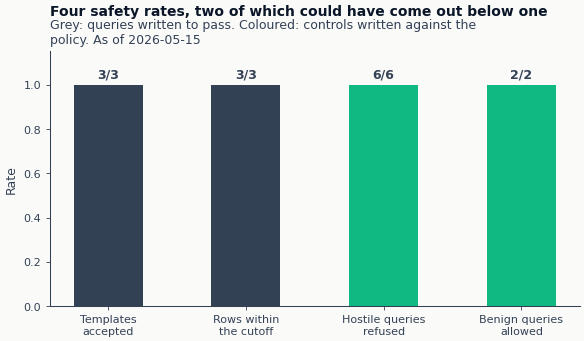

In [19]:
fig, ax = plt.subplots(figsize=FIGSIZE["single"], constrained_layout=True)
metric_names = [
    "Templates\naccepted",
    "Rows within\nthe cutoff",
    "Hostile queries\nrefused",
    "Benign queries\nallowed",
]
metric_values = [
    metrics["templates_accepted"] / n,
    metrics["rows_within_cutoff"] / n,
    hostile_reject_rate,
    benign_accept_rate,
]
metric_denominators = [n, n, len(MUST_REJECT), len(MUST_ACCEPT)]
colors = [COLORS["neutral"], COLORS["neutral"], COLORS["positive"], COLORS["positive"]]
bars = ax.bar(metric_names, metric_values, color=colors, width=0.5)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Rate")
add_message_title(
    ax,
    "Four safety rates, two of which could have come out below one",
    subtitle=(
        "Grey: queries written to pass. Coloured: controls written against the policy. "
        f"As of {CUTOFF_DATE}"
    ),
)
for bar, val, denom in zip(bars, metric_values, metric_denominators, strict=True):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.03,
        f"{round(val * denom)}/{denom}",
        ha="center",
        fontweight="bold",
    )
show_with_alt(
    fig,
    "Four bars on a rate axis from zero to one, each labelled with its count. In grey, "
    f"templates accepted {metrics['templates_accepted']} of {n} and rows within the "
    f"cutoff {metrics['rows_within_cutoff']} of {n}. In colour, hostile queries refused "
    f"{rejected} of {len(MUST_REJECT)} and benign queries allowed {accepted_benign} of "
    f"{len(MUST_ACCEPT)}. All four bars reach the top of the axis. The two grey bars are "
    "over queries built to pass and could not have come out lower; the two coloured bars "
    "are over controls written against the policy and could have.",
)

### Machine-Readable Completion Record

In [20]:
completion_record = {
    "source_sha256": expected_source_hash,
    "formation_report_date": GRAPH_SNAPSHOT["formation_report_date"],
    "latest_report_date": GRAPH_SNAPSHOT["latest_report_date"],
    "cutoff_date": CUTOFF_DATE,
    **graph_counts,
    "query_count": n,
    "co_owner_date_fields": 2,
    **metrics,
    "hostile_queries": len(MUST_REJECT),
    "hostile_rejected": rejected,
    "benign_queries": len(MUST_ACCEPT),
    "benign_accepted": accepted_benign,
    "asof_latest_availability": asof_latest_q,
    "earlier_cutoff": EARLIER_CUTOFF,
    "earlier_latest_availability": earlier_latest_q,
    "shared_holders": len(shared_holders),
    "shifted_holders": len(shifted_holders),
}
print("COMPLETION_RECORD=" + json.dumps(completion_record, sort_keys=True))
NEO4J_DRIVER.close()

COMPLETION_RECORD={"asof_latest_availability": "2026-05-15", "benign_accepted": 2, "benign_queries": 2, "co_owner_date_fields": 2, "cutoff_date": "2026-05-15", "earlier_cutoff": "2026-02-17", "earlier_latest_availability": "2026-02-17", "formation_report_date": "2025-06-30", "holdings": 1463, "hostile_queries": 6, "hostile_rejected": 6, "institutions": 10, "latest_report_date": "2026-03-31", "query_count": 3, "rows_within_cutoff": 3, "sector_edges": 50, "shared_holders": 8, "shifted_holders": 8, "source_sha256": "d2a67317195dd431f00e3408c1ba4e6bf8b44b3eae2f838cbbd90fabca69ef0d", "stocks": 50, "templates_accepted": 3}


## Key Takeaways

1. **A rate over inputs chosen to pass is not a measurement.** The original
   three diagnostics were 3/3, 3/3 and 3/3 over three templates this notebook
   wrote against its own validator, and one of the three was implied by
   another - a date that satisfies `<= cutoff` is also truthy, so the
   provenance bar could never differ from the temporal one. The control set in
   section 6 is what makes the accept and reject rates capable of coming out
   below one.

2. **A text policy over a query language fails in both directions.** It
   accepted `MATCH (n) RETURN n LIMIT 1000 // $cutoff_date`, which scans every
   node in the database while satisfying the cutoff check with a comment, and
   it refused a query whose issuer name contains "RECALL" for looking like a
   `CALL` procedure. Comments and string literals are stripped before the text
   checks now, keywords match on word boundaries, every node pattern must name
   a label, and an explicit `LIMIT` is compared against `ROW_LIMIT` rather than
   merely counted as present.

3. **Nothing here generates Cypher.** Three templates with fixed parameters
   are matched to three questions; the entity in the question is never read.
   That is what makes the pipeline safe, and the validator is a second line
   rather than the guarantee. Calling it text-to-Cypher oversold it.

4. **The two dates on a HOLDS edge answer different questions.** The cutoff
   compares against `available_from`, when a filing became public; the
   latest-per-pair ordering uses `report_date`, the quarter the position
   describes. Swapping them admits a filing that had not been made yet.

5. **The cutoff is read from the producer, not restated.** This notebook
   asserted `latest_quarter == "2026-02-17"` and stopped working the day the
   13F artifact rolled forward a quarter. It now takes the date from the
   `GraphSnapshot` node that `05_institutional_holdings_kg` writes, and the
   negative control takes its earlier date from the graph's own availability
   dates.

**Next**: `04_rag_comparison_benchmark` measures what an embedding retriever
recovers from the same holdings, against the relational lookups used here.
Provenance coverage ensures every returned row carries its filing date.

## 6. Notes

- This notebook executes against the live holdings graph rather than canned rows.
- Production deployment should add server-side query whitelisting, RBAC,
  query plan checks, and audit logging.

## Key Takeaways

1. **Template-based safety** keeps the text-to-Cypher surface narrow enough to audit.
2. **Schema enforcement** blocks labels, relationships, and properties outside the holdings graph.
3. **Cutoff-date parameters** preserve point-in-time correctness for historical questions.
4. **Live graph execution** is only credible when Neo4j is actually populated with the chapter's 13F data.

**Next**: See `04_rag_comparison_benchmark.py` for a real-data retrieval benchmark
comparing structured graph retrieval with vector retrieval over the same holdings corpus.